# Part 6 - Interoperability and the temporal downstream task

The same object exports to three backends - igraph, Cytoscape (CX2), and
PyTorch-Geometric - and backs a graph-neural-network experiment that uses the
*time* aspect directly: forecasting the next-step response. The cell below reloads
the graph and rebuilds the derived tables the sections use.

In [1]:
import time
from collections import Counter

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import torch

import annnet as an
import uc2b_common as uc

G = uc.load()
verts_df = G.views.vertices().to_pandas()
edges_df = G.views.edges().to_pandas()
responsive = pl.read_parquet(str(uc.RESPONSIVE)).to_pandas()
resp_at = uc.responsive_by_time(responsive)
TF_SET = set(pl.read_csv(str(uc.DATA / "dorothea.tsv"), separator="\t",
                         infer_schema_length=5000)["source_genesymbol"])

CX2_OUT, PYG_OUT = uc.OUT / "signaling.cx2", uc.OUT / "heterodata.pt"
HISTORY_OUT = uc.OUT / "history.json"
INPUT_TIMES = ("1h", "12h", "24h", "48h", "72h")   # forecast the 96h response
GNN_HIDDEN, GNN_LR, GNN_EPOCHS, GNN_SEEDS = 64, 1e-2, 60, 3


def time_of(repr_str):
    inner = repr_str[repr_str.find("(", 2):]
    for t in uc.ALL_TIMES:
        if f"'{t}'" in inner:
            return t

def mech_of(repr_str):
    return (uc.MECH_SIGNALING if "'signaling'" in repr_str
            else uc.MECH_REGULATORY if "'regulatory'" in repr_str else None)

print("reloaded graph:", G.global_count("vertices"), "vertices,", G.global_count("edges"), "edges")

reloaded graph: 19587 vertices, 63891 edges


## 6.1 Backend swap - igraph Leiden on the signaling network

`G.ig` converts the whole graph on first use (cached). Inducing on
`edge_kind='signaling'` collects the signaling edges across *all* time layers into
one network - a signaling edge is a signaling edge whichever timepoint holds it -
so Leiden clusters the time-union signaling backbone. The cluster ids write back as
a vertex attribute on the same AnnNet object.

In [2]:
t0 = time.perf_counter()
ig_full = G.ig.backend()
sig_edges = ig_full.es.select(edge_kind="signaling")
ig_g = ig_full.subgraph_edges(sig_edges, delete_vertices=True)
print(f"AnnNet -> igraph, induce signaling : {time.perf_counter() - t0:.2f}s  "
      f"(|V|={ig_g.vcount():,} |E|={ig_g.ecount():,})")

t0 = time.perf_counter()
partition = ig_g.as_undirected().community_leiden(objective_function="modularity", n_iterations=5)
print(f"Leiden                             : {time.perf_counter() - t0:.2f}s  -> {len(partition):,} communities")

names = ig_g.vs["name"] if "name" in ig_g.vs.attributes() else [str(v.index) for v in ig_g.vs]
membership = {uc.bare_vid(n): c for n, c in zip(names, partition.membership)}
G.attrs.set_vertex_attrs_bulk({v: {"leiden_signaling_community": int(c)}
                               for v, c in membership.items()
                               if isinstance(v, str) and v.startswith("prot:")})
G.history.snapshot("after_backend_swap")
print(f"top community sizes: {Counter(membership.values()).most_common(5)}")

/mnt/c/Users/pc/desktop/annnet-remote/annnet/core/backend_accessors/_base.py:164: RuntimeWarning: AnnNet-igraph conversion is lossy: hyperedges dropped (hyperedge_mode='skip'); multiple slices flattened into single igraph graph.
  entry = dict(build())


AnnNet -> igraph, induce signaling : 2.09s  (|V|=8,643 |E|=26,330)
Leiden                             : 0.05s  -> 201 communities


top community sizes: [(0, 1483), (4, 392), (5, 378), (3, 310), (8, 215)]


## 6.2 Provenance - snapshot diff

Each build stage called `G.history.snapshot(label)`. `G.history.diff(a, b)` returns
the structural delta between any two snapshots, reconstructing the build after the
fact.

In [3]:
labels = [s["label"] if isinstance(s, dict) else s for s in G.history.list_snapshots()]
seen, order = set(), []
for lab in labels:               # de-duplicate labels from re-runs, keep first order
    if lab not in seen:
        seen.add(lab); order.append(lab)
diffs = []
for a, b in zip(order, order[1:]):
    d = G.history.diff(a, b).to_dict()
    diffs.append({"from": a, "to": b,
                  "V_added": len(d["vertices_added"]), "E_added": len(d["edges_added"]),
                  "slices_added": len(d["slices_added"])})
diff_df = pd.DataFrame(diffs)
diff_df.to_csv(uc.TABLES / "history_diffs.csv", index=False)
print(diff_df.to_string(index=False))
G.history.export(str(HISTORY_OUT))
print(f"\nHistory exported -> {HISTORY_OUT.name}")

                  from                     to  V_added  E_added  slices_added
                  init         after_response     5615    36492             0
        after_response         after_coupling        0    10982             0
        after_coupling          after_complex     5517     3446             0
         after_complex        after_metabolic     8455    12971            10
       after_metabolic after_organelle_slices        0        0             9
after_organelle_slices     after_backend_swap        0        0             0

History exported -> history.json


## 6.3 CX2 export for Cytoscape

`to_cx2` writes the graph as CX2. Cytoscape has no hyperedge primitive, so
`hyperedges='skip'` drops them; the binary signaling, regulatory, and coupling
edges (across every time layer) export. For a lossless round-trip use the `.annnet`
format (6.6); CX2 targets Cytoscape display.

In [4]:
cx2_data = an.to_cx2(G, path=str(CX2_OUT), export_name="UC2b - time-resolved backbone",
                    hyperedges="skip")
print(f"CX2 aspects written : {len(cx2_data)}")
print(f"File                 : {CX2_OUT.name}  ({CX2_OUT.stat().st_size / 1e3:.1f} KB)")

CX2 aspects written : 7
File                 : signaling.cx2  (19457.2 KB)


## 6.4 PyG `HeteroData` export

`to_pyg` builds one node type per vertex `kind` (gene, protein, metabolite,
boundary). The node typing comes from `kind`, not from the aspect coordinate, so
this export flattens the time layers; section 6.5 builds its own time-aware view.
The export skips hyperedges, so complexes and metabolism are absent here (they
remain in `G` and the `.annnet` snapshot).

In [5]:
t0 = time.perf_counter()
hetero = an.to_pyg(G, hyperedge_mode="skip")
print(f"AnnNet -> PyG HeteroData : {time.perf_counter() - t0:.2f}s")
for nt in hetero.node_types:
    print(f"  {nt:<12s} n={hetero[nt].num_nodes:,}")
for et in hetero.edge_types:
    n = hetero[et].edge_index.size(1) if "edge_index" in hetero[et] else 0
    print(f"  {str(et):<40s} m={n:,}")
torch.save(hetero, PYG_OUT)
print(f"saved -> {PYG_OUT.name}")

/home/l1boll/miniconda3/envs/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnNet -> PyG HeteroData : 2.78s
  protein      n=9,006
  gene         n=2,126
  metabolite   n=8,455
  ('protein', 'edge', 'protein')           m=30,950
  ('gene', 'edge', 'gene')                 m=13,202
  ('gene', 'edge', 'protein')              m=3,322
saved -> heterodata.pt


## 6.5 Next-step response forecasting

This is the task the time aspect makes natural: **given only the multilayer graph
up to 72h, forecast which genes join the response at 96h.** The candidates are the
genes that appear in the regulatory layers at 1h-72h; the positives are those
responsive at 96h but *not* at 72h (the 96h-specific responders, base rate ~7%).
No 96h layer, and no 96h attribute, enters the graph or the features, so the target
cannot leak.

The graph is built over the *supra-nodes* `(entity, mechanism, t)` for t <= 72h, so
message passing runs on the real time layers. The ablation adds edge families one at
a time; the last is **time-coupling**, the diagonal edges that let earlier-timepoint
signal propagate forward. As in UC2, the channel gains are small relative to the
seed spread - the point is that a temporal, multilayer, multi-source forecasting
task is a handful of cells on one object.

In [6]:
try:
    from torch_geometric.nn import SAGEConv
    from sklearn.metrics import roc_auc_score, average_precision_score
    import torch.nn.functional as F
    GNN = True
except ImportError as e:
    GNN = False
    print(f"torch_geometric / sklearn unavailable: {e}\nSkipping GNN section.")

In [7]:
if GNN:
    lfc_at = {(r.symbol, r.time): r.best_logFC for r in responsive.itertuples()}
    node_id, edges = {}, {k: [] for k in
                          ["signaling", "regulatory", "coupling_time", "coupling_translation"]}

    def nid(bare, mech, t):
        return node_id.setdefault((bare, mech, t), len(node_id))

    for r in edges_df.itertuples(index=False):
        if r.edge_kind not in edges:
            continue
        ta, tb = time_of(r.source), time_of(r.target)
        ma, mb = mech_of(r.source), mech_of(r.target)
        if ta in INPUT_TIMES and tb in INPUT_TIMES and ma and mb:
            edges[r.edge_kind].append(
                (nid(uc.bare_vid(r.source), ma, ta), nid(uc.bare_vid(r.target), mb, tb)))

    N = len(node_id)
    tidx = {t: i for i, t in enumerate(INPUT_TIMES)}
    X = torch.zeros(N, 5)
    for (bare, mech, t), i in node_id.items():
        sym = bare.split(":", 1)[1]
        X[i, 0] = float(mech == uc.MECH_SIGNALING)
        X[i, 1] = float(mech == uc.MECH_REGULATORY)
        X[i, 2] = tidx[t] / (len(INPUT_TIMES) - 1)
        X[i, 3] = float(sym in TF_SET)
        X[i, 4] = float(lfc_at.get((sym, t), 0.0))

    # candidate genes = latest regulatory supra-node <= 72h; positive = 96h-specific.
    latest = {}
    for (bare, mech, t), i in node_id.items():
        if mech != uc.MECH_REGULATORY:
            continue
        sym = bare.split(":", 1)[1]
        if sym not in latest or tidx[t] > tidx[latest[sym][1]]:
            latest[sym] = (i, t)
    r72, r96 = resp_at.get("72h", set()), resp_at.get("96h", set())
    cands = sorted(latest)
    y = np.array([1 if (s in r96 and s not in r72) else 0 for s in cands])
    rep = np.array([latest[s][0] for s in cands])
    print(f"supra-nodes N={N:,} | candidate genes={len(cands):,} | "
          f"96h-specific positives={int(y.sum())} ({y.mean():.1%} base rate)")
    print("edge families:", {k: len(v) for k, v in edges.items()})

supra-nodes N=9,322 | candidate genes=1,543 | 96h-specific positives=108 (7.0% base rate)
edge families: {'signaling': 15410, 'regulatory': 6570, 'coupling_time': 4841, 'coupling_translation': 2139}


In [8]:
if GNN:
    rng = np.random.default_rng(uc.SEED)
    perm = rng.permutation(len(cands))
    te, tr = perm[:int(0.3 * len(cands))], perm[int(0.3 * len(cands)):]
    yt = torch.tensor(y, dtype=torch.float32)
    ridx = torch.tensor(rep, dtype=torch.long)
    UNDIR = {"signaling", "regulatory", "coupling_translation"}  # time-coupling stays forward

    def edge_index(keys):
        ei = [e for k in keys for e in edges[k]]
        t = torch.tensor(ei, dtype=torch.long).t().contiguous() if ei else torch.zeros(2, 0, dtype=torch.long)
        rev = [e for k in keys if k in UNDIR for e in edges[k]]
        if rev:
            t = torch.cat([t, torch.tensor(rev, dtype=torch.long).t().flip(0)], dim=1)
        return t

    class Net(torch.nn.Module):
        def __init__(self, hid):
            super().__init__()
            self.c1, self.c2 = SAGEConv(5, hid), SAGEConv(hid, hid)
            self.lin = torch.nn.Linear(hid, 1)

        def forward(self, x, ei):
            return self.c2(self.c1(x, ei).relu(), ei).relu()

    def run(keys, seed):
        torch.manual_seed(seed)
        ei = edge_index(keys)
        model, opt = Net(GNN_HIDDEN), None
        opt = torch.optim.Adam(model.parameters(), lr=GNN_LR)
        for _ in range(GNN_EPOCHS):
            model.train(); opt.zero_grad()
            h = model(X, ei)
            loss = F.binary_cross_entropy_with_logits(model.lin(h[ridx[tr]]).squeeze(-1), yt[tr])
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            p = torch.sigmoid(model.lin(model(X, ei)[ridx[te]]).squeeze(-1)).numpy()
        return roc_auc_score(y[te], p), average_precision_score(y[te], p)

    configs = [("features + regulatory", ["regulatory"]),
               ("+ signaling", ["regulatory", "signaling"]),
               ("+ translation", ["regulatory", "signaling", "coupling_translation"]),
               ("+ time-coupling", ["regulatory", "signaling", "coupling_translation", "coupling_time"])]
    ab = []
    for tag, keys in configs:
        res = [run(keys, uc.SEED + s) for s in range(GNN_SEEDS)]
        auc, ap = np.mean([r[0] for r in res]), np.mean([r[1] for r in res])
        ab.append({"config": tag, "n_families": len(keys), "auroc": auc,
                   "auroc_std": np.std([r[0] for r in res]), "ap": ap})
        print(f"{tag:<24s} AUROC={auc:.3f} +/- {np.std([r[0] for r in res]):.3f}  AP={ap:.3f}")
    ab_df = pd.DataFrame(ab)
    ab_df.to_csv(uc.TABLES / "gnn_forecast_ablation.csv", index=False)
    print(f"\nbase rate {y.mean():.3f} -> AUROC {ab_df.auroc.iloc[0]:.3f} (features+reg) "
          f".. {ab_df.auroc.max():.3f} (best); gains within seed std ~{ab_df.auroc_std.median():.3f}.")
    print("The forecast is well above chance; the multi-source channels move it only")
    print("modestly - the deliverable is the temporal task in a handful of cells, on one object.")

features + regulatory    AUROC=0.922 +/- 0.006  AP=0.299


+ signaling              AUROC=0.922 +/- 0.006  AP=0.299


+ translation            AUROC=0.934 +/- 0.015  AP=0.367


+ time-coupling          AUROC=0.928 +/- 0.010  AP=0.376

base rate 0.070 -> AUROC 0.922 (features+reg) .. 0.934 (best); gains within seed std ~0.008.
The forecast is well above chance; the multi-source channels move it only
modestly - the deliverable is the temporal task in a handful of cells, on one object.


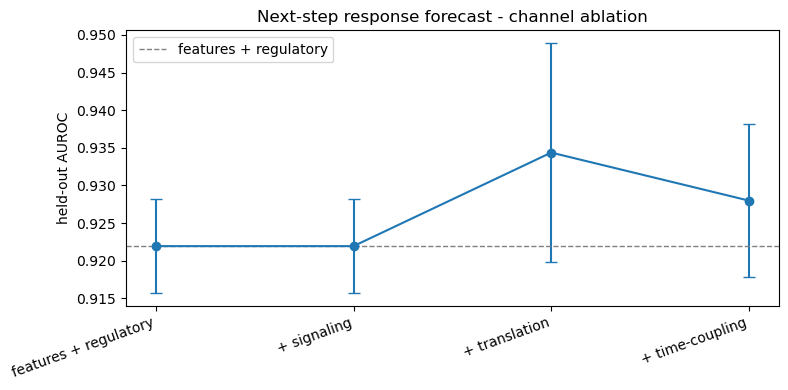

In [9]:
if GNN:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.errorbar(range(len(ab_df)), ab_df.auroc, yerr=ab_df.auroc_std, marker="o", capsize=4)
    ax.set_xticks(range(len(ab_df))); ax.set_xticklabels(ab_df.config, rotation=20, ha="right")
    ax.set_ylabel("held-out AUROC"); ax.set_title("Next-step response forecast - channel ablation")
    ax.axhline(ab_df.auroc.iloc[0], ls="--", c="gray", lw=1, label="features + regulatory")
    ax.legend(); fig.tight_layout(); fig.savefig(uc.FIGS / "gnn_forecast_ablation.png", dpi=120); plt.show()

## 6.6 Save the AnnNet snapshot

One `.annnet` file round-trips the whole graph: both aspects, hyperedges, slices,
coupling, attributes, and history.

In [10]:
G.history.snapshot("final")
G.write(str(uc.SNAPSHOT), overwrite=True)
print(f"Wrote {uc.SNAPSHOT.name} ({uc.SNAPSHOT.stat().st_size / 1e6:.2f} MB)")
G2 = an.AnnNet.read(str(uc.SNAPSHOT))
print(f"Roundtrip: |V|={G2.global_count('vertices'):,} |E|={G2.global_count('edges'):,} "
      f"aspects={G2.layers.list_aspects()} slices={len(G2.slices.list()):,}")

Wrote uc2b.annnet (5.31 MB)


Roundtrip: |V|=19,587 |E|=63,891 aspects=('mechanism', 'time') slices=20
